# Section 1 — Environment Setup

In [ ]:
# ============================================================
# Section 1: Environment Setup
# Import all required libraries for data processing,
# modelling, and evaluation. Handle sklearn version
# differences for OneHotEncoder sparse matrix argument.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import __version__ as sklearn_version

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Handle sparse matrix keyword change in sklearn >= 1.2
SKL_VERSION = tuple(
    int(x) for x in sklearn_version.split('.')[:2]
)
OHE_SPARSE_KW = (
    {'sparse_output': False}
    if SKL_VERSION >= (1, 2)
    else {'sparse': False}
)
print(f"sklearn {sklearn_version}")

sklearn 1.6.1


# Section 2 — Data Loading

In [ ]:
# ============================================================
# Section 2: Data Loading
# Mount Google Drive and load all 4 datasets:
#   - transactions_data_training.csv  (raw transactions)
#   - transaction_types.csv           (type → direction map)
#   - mcc_group_definition.csv        (merchant categories)
#   - user_profile.csv                (user demographics)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

base = '/content/drive/MyDrive/N26'

df_txn     = pd.read_csv(f'{base}/transactions_data_training.csv')
df_types   = pd.read_csv(f'{base}/transaction_types.csv')
df_mcc     = pd.read_csv(f'{base}/mcc_group_definition.csv')
df_profile = pd.read_csv(f'{base}/user_profile.csv')

# Confirm structure before any processing
print("Transactions columns:", df_txn.columns.tolist())
print("Transactions shape:  ", df_txn.shape)
print("Unique users:        ", df_txn['user_id'].nunique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Transactions columns: ['user_id', 'transaction_date', 'transaction_type', 'mcc_group', 'amount_n26_currency', 'dataset_transaction', 'dataset_user']
Transactions shape:   (408546, 7)
Unique users:         10000


# Section 3 — Data Cleaning & Validation

In [ ]:
# ============================================================
# Section 3: Data Cleaning & Validation
# Three cleaning steps:
#   1. Drop meta columns added by StrataScratch
#      (dataset_transaction, dataset_user) — no signal
#   2. Parse transaction_date string → datetime object
#      so we can extract month, day, span etc.
#   3. Replace string "NA" in mcc_group with real NaN
#      (only card transactions have an MCC group;
#       bank transfers use the string "NA" as placeholder)
# ============================================================

# Drop StrataScratch metadata columns
df_txn = df_txn.drop(
    columns=['dataset_transaction', 'dataset_user']
)

# Parse date column for temporal feature engineering
df_txn['transaction_date'] = pd.to_datetime(
    df_txn['transaction_date']
)

# Fix mcc_group: "NA" string → real NaN
df_txn['mcc_group'] = df_txn['mcc_group'].replace(
    'NA', np.nan
)

# Sanity check: confirm shapes, dtypes, missing values
print("=== Transactions ===")
print(df_txn.shape)
print(df_txn.dtypes)
print(df_txn.isnull().sum())
print(df_txn.head(3))

print("\n=== Transaction Types ===")
print(df_types)

print("\n=== MCC Groups ===")
print(df_mcc)

print("\n=== User Profile ===")
print(df_profile.shape)
print(df_profile.head(3))

=== Transactions ===
(408546, 5)
user_id                        object
transaction_date       datetime64[ns]
transaction_type               object
mcc_group                     float64
amount_n26_currency             int64
dtype: object
user_id                     0
transaction_date            0
transaction_type            0
mcc_group              150222
amount_n26_currency         0
dtype: int64
                            user_id transaction_date transaction_type  \
0  a78884f5e76951188c1e719d4956773a       2016-02-01               DT   
1  b0333294fef6ff1299102a70ad46b126       2016-02-01               DT   
2  7b8d2a2780adae0cd0c248e92c1b28dc       2016-02-01               DT   

   mcc_group  amount_n26_currency  
0        NaN                  350  
1        NaN                  202  
2        NaN                  291  

=== Transaction Types ===
   type                        explanation direction         agent
0    AR               Authorization reject         -          Card
1 

# Section 4 — Direction Mapping & Transaction Filtering

In [ ]:
# ============================================================
# Section 4: Direction Mapping & Transaction Filtering
# Join transactions with transaction_types to get the
# flow direction (In / Out / -) for each transaction.
#
# Filtering rules:
#   - Keep only direction = "In" or "Out"
#   - Exclude direction = "-" (AR = rejected, no money moved)
#   - Exclude Shadow agent types (AL, AU, BUS, BRU)
#     which are internal N26 accounting entries,
#     not real user behaviour
# ============================================================

# Build direction lookup: transaction type code → In/Out/-
direction_map = (
    df_types.set_index('type')['direction']
    .to_dict()
)

# Map direction onto every transaction row
df_txn['direction'] = (
    df_txn['transaction_type'].map(direction_map)
)

# Define internal Shadow transaction types to exclude
SHADOW_TYPES = ['AL', 'AU', 'BUS', 'BRU']

# Filter: keep only real In/Out transactions,
# excluding Shadow and rejected types
df_valid = df_txn[
    df_txn['direction'].isin(['In', 'Out']) &
    ~df_txn['transaction_type'].isin(SHADOW_TYPES)
].copy()

# Verify all amounts are positive
assert (df_valid['amount_n26_currency'] > 0).all(), \
    "Found non-positive amounts!"

print(f"Total raw transactions : {len(df_txn):,}")
print(f"Valid transactions     : {len(df_valid):,}")
print(f"Dropped (Shadow + '-') : {len(df_txn) - len(df_valid):,}")
print()
print("Remaining transaction types:")
print(df_valid['transaction_type'].value_counts())

Total raw transactions : 408,546
Valid transactions     : 408,546
Dropped (Shadow + '-') : 0

Remaining transaction types:
transaction_type
PT     258324
CT      63837
DT      40528
DD      29869
FT       6528
DR       4727
BBU      3561
BUB       942
TUB       230
Name: count, dtype: int64


# Section 5 — User Profile Cleaning

In [ ]:
# ============================================================
# Section 5: User Profile Cleaning
# Drop 'age_band' — it is a bucketed string version of 'age'
# (e.g. "45-54"). Since we already have the exact numeric
# 'age' column, age_band is redundant and adds no new signal.
# Keeping both would introduce multicollinearity.
# ============================================================

df_profile_clean = df_profile.drop(
    columns=['age_band'],
    errors='ignore',
)
print(f"Profile columns: {list(df_profile_clean.columns)}")

Profile columns: ['user_id', 'age', 'country', 'city_tier', 'employment_status', 'industry', 'income_band', 'account_tenure_days']


# Section 6 — Exploratory Data Analysis (EDA)

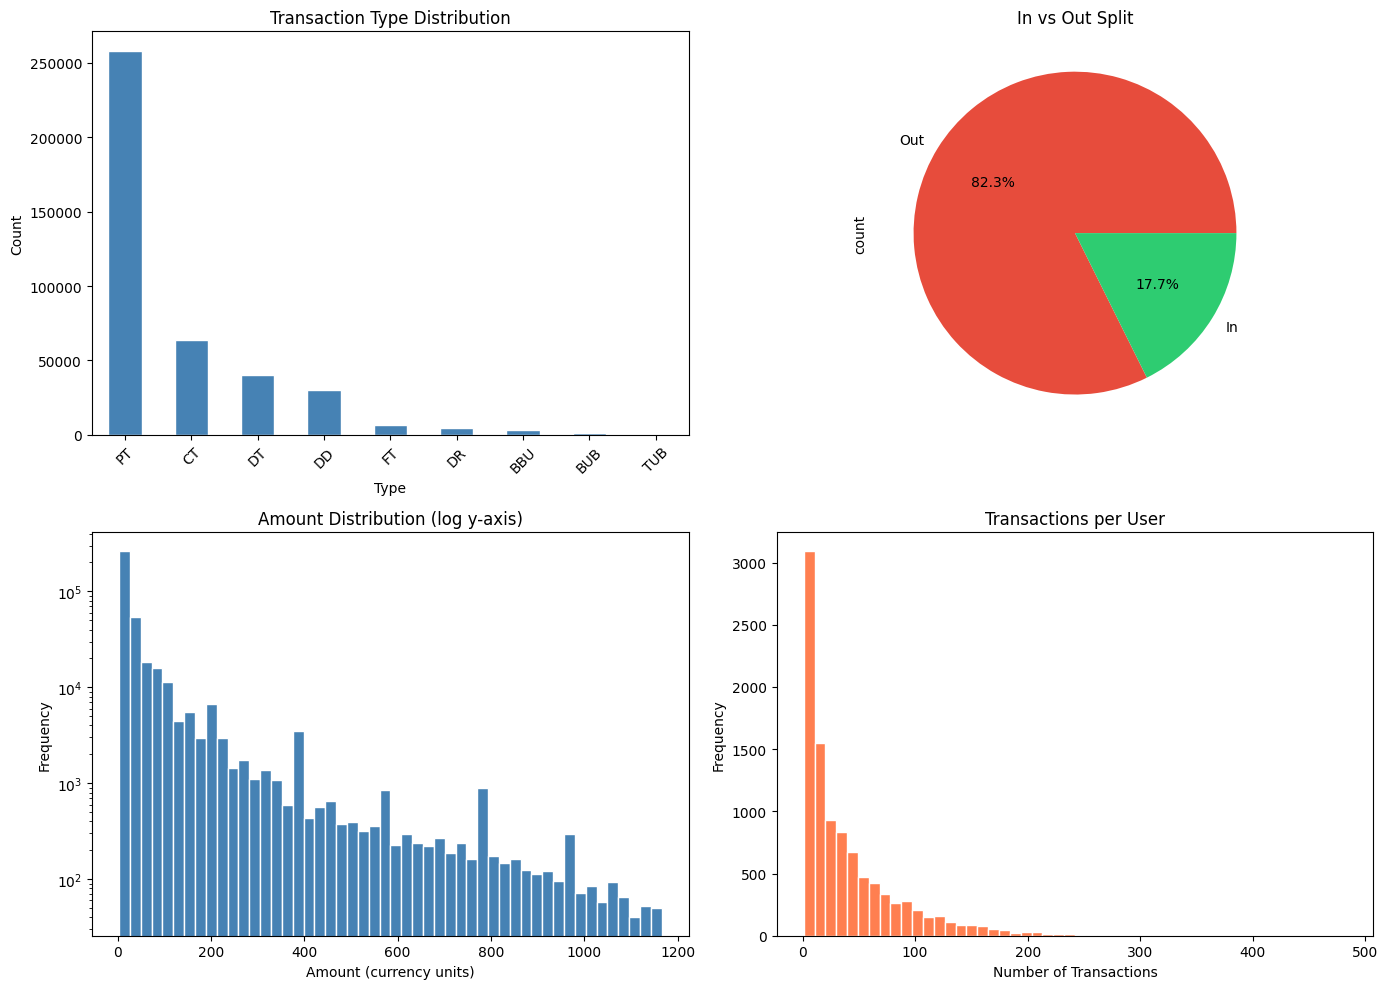

=== Amount Stats ===
count   408546.00
mean        52.76
std        111.87
min          3.00
25%          7.00
50%         17.00
75%         38.00
max       1166.00
Name: amount_n26_currency, dtype: float64

Median transactions per user : 23
Max transactions per user    : 483
Min transactions per user    : 1


In [ ]:
# ============================================================
# Section 6: Exploratory Data Analysis
# Four plots to understand the data before modelling:
#   1. Transaction type distribution — what types dominate?
#   2. In vs Out split — how much is spending vs income?
#   3. Amount distribution (log y-axis) — how skewed?
#   4. Transactions per user — how active are users?
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Transaction type frequency
df_valid['transaction_type'].value_counts().plot(
    kind='bar', ax=axes[0, 0],
    color='steelblue', edgecolor='white'
)
axes[0, 0].set_title('Transaction Type Distribution')
axes[0, 0].set_xlabel('Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. In vs Out proportion
df_valid['direction'].value_counts().plot(
    kind='pie', ax=axes[0, 1], autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71']
)
axes[0, 1].set_title('In vs Out Split')

# 3. Amount distribution — log y-axis reveals the long tail
df_valid['amount_n26_currency'].plot(
    kind='hist', bins=50, ax=axes[1, 0],
    color='steelblue', edgecolor='white', logy=True
)
axes[1, 0].set_title('Amount Distribution (log y-axis)')
axes[1, 0].set_xlabel('Amount (currency units)')

# 4. Transactions per user — most users have < 50 transactions
txn_per_user = df_valid.groupby('user_id').size()
txn_per_user.plot(
    kind='hist', bins=50, ax=axes[1, 1],
    color='coral', edgecolor='white'
)
axes[1, 1].set_title('Transactions per User')
axes[1, 1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()

# Key statistics
print("=== Amount Stats ===")
print(df_valid['amount_n26_currency'].describe())
print(f"\nMedian transactions per user : {txn_per_user.median():.0f}")
print(f"Max transactions per user    : {txn_per_user.max()}")
print(f"Min transactions per user    : {txn_per_user.min()}")

In [ ]:
# User profile categorical breakdown
print("=== User Profile Stats ===")
print(df_profile_clean.describe())
print()
print("=== Categorical Columns ===")
for col in ['country', 'employment_status',
            'industry', 'income_band']:
    print(f"\n{col}:")
    print(df_profile_clean[col].value_counts())

=== User Profile Stats ===
          age  city_tier  account_tenure_days
count 9470.00    9470.00              9470.00
mean    43.36       2.00               129.60
std      9.31       0.63                27.01
min     21.00       1.00                66.00
25%     37.00       2.00               109.00
50%     43.00       2.00               130.00
75%     50.00       2.00               151.00
max     67.00       3.00               194.00

=== Categorical Columns ===

country:
country
DE    5158
AT    1299
ES    1142
FR    1023
IE     848
Name: count, dtype: int64

employment_status:
employment_status
employed_ft      4462
self_employed    1529
unemployed       1377
employed_pt       940
retired           908
student           254
Name: count, dtype: int64

industry:
industry
other            3172
technology       1050
healthcare        883
services          841
retail            809
finance           774
hospitality       772
manufacturing     625
education         544
Name: count, dtyp

#  Section 7 — Temporal Split & Target Construction

In [ ]:
# ============================================================
# Section 7: Temporal Split & Target Construction
#
# Design: feature window → target window (no data leakage)
#   Feature window: Feb–May 2016 (4 months of history)
#   Target window:  Jun–Jul 2016 (2 months to predict)
#
# This mirrors real production ML — we use past behaviour
# to predict future spending, never the reverse.
#
# Targets per user (summed over target window):
#   total_income   = sum of all "In"  transaction amounts
#   total_expenses = sum of all "Out" transaction amounts
#
# Users with zero activity in target window are kept as 0
# (churned users are a real business scenario, not noise).
# ============================================================

# Verify data covers both windows
print("Date range in data:")
print(df_valid['transaction_date'].min())
print(df_valid['transaction_date'].max())

# Define window boundaries
FEAT_START = '2016-02-01'
FEAT_END   = '2016-05-31'
TGT_START  = '2016-06-01'
TGT_END    = '2016-07-31'

# Split transactions into feature and target windows
df_feat_window = df_valid[
    (df_valid['transaction_date'] >= FEAT_START) &
    (df_valid['transaction_date'] <= FEAT_END)
]
df_tgt_window = df_valid[
    (df_valid['transaction_date'] >= TGT_START) &
    (df_valid['transaction_date'] <= TGT_END)
]

print(f"Feature window : {len(df_feat_window):,} txns "
      f"({FEAT_START} to {FEAT_END})")
print(f"Target window  : {len(df_tgt_window):,} txns "
      f"({TGT_START} to {TGT_END})")

# Build per-user targets from target window only
model_users = sorted(df_feat_window['user_id'].unique())

tgt_in = (
    df_tgt_window[df_tgt_window['direction'] == 'In']
    .groupby('user_id')['amount_n26_currency'].sum()
)
tgt_out = (
    df_tgt_window[df_tgt_window['direction'] == 'Out']
    .groupby('user_id')['amount_n26_currency'].sum()
)

# Align to model_users — users with no activity get 0
targets = pd.DataFrame(index=model_users)
targets.index.name = 'user_id'
targets['total_income']   = tgt_in.reindex(model_users).fillna(0)
targets['total_expenses'] = tgt_out.reindex(model_users).fillna(0)

# Report churn: users with zero income AND zero expenses
n_churn = (
    (targets['total_income'] == 0) &
    (targets['total_expenses'] == 0)
).sum()
print(f"\nPopulation : {len(model_users):,} users "
      f"({n_churn:,} churned = target 0)")
print(targets.describe().to_string())

Date range in data:
2016-02-01 00:00:00
2016-07-31 00:00:00
Feature window : 267,593 txns (2016-02-01 to 2016-05-31)
Target window  : 140,953 txns (2016-06-01 to 2016-07-31)

Population : 9,470 users (1,642 churned = target 0)
       total_income  total_expenses
count       9470.00         9470.00
mean         352.09          425.06
std          570.40          778.00
min            0.00            0.00
25%            0.00           13.00
50%          112.00          136.00
75%          465.00          521.00
max         7820.00        14603.00


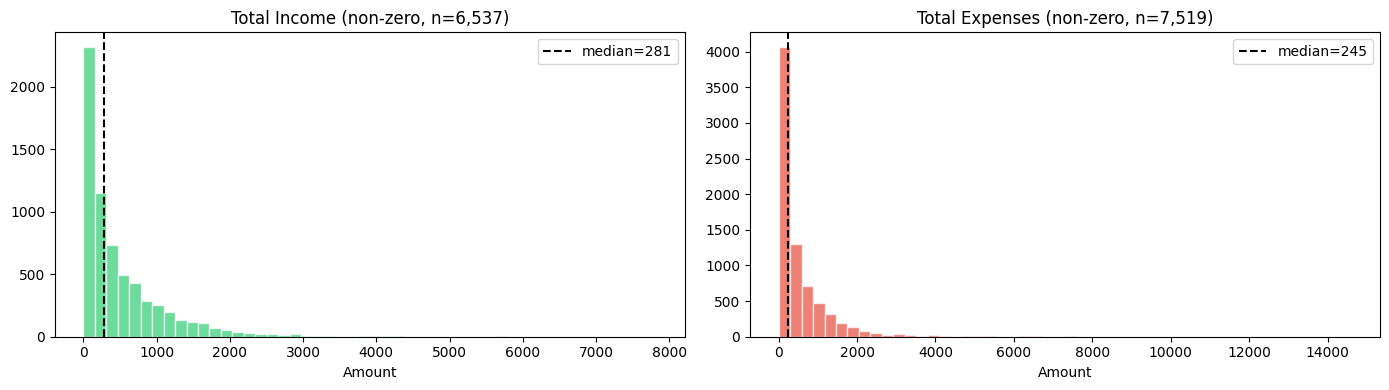

In [ ]:
# ── Target distribution plots ────────────────────────────────
# Plot non-zero values only — churned users (value=0) would
# compress the histogram and obscure the real distribution.
# Median line added for reference.

fig_targets, axs_tgt = plt.subplots(1, 2, figsize=(14, 4))

for i, (col, color) in enumerate([
    ('total_income',   '#2ecc71'),
    ('total_expenses', '#e74c3c'),
]):
    ax  = axs_tgt[i]
    nz  = targets[col][targets[col] > 0]
    ax.hist(nz, bins=50, color=color,
            alpha=0.7, edgecolor='white')
    ax.set_title(
        f'{col.replace("_", " ").title()} '
        f'(non-zero, n={len(nz):,})'
    )
    ax.set_xlabel('Amount')
    ax.axvline(nz.median(), color='black', ls='--',
               label=f'median={nz.median():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Section 8 — Feature Engineering

In [ ]:
# ============================================================
# Section 8: Feature Engineering
# Build per-user aggregate features from FEATURE WINDOW only.
# Wrapped in a function so it can be called on any time window.
#
# Five feature groups:
#   1. Counts     — volume of activity (n_transactions etc.)
#   2. Amounts    — spending/income levels (mean, sum, std)
#   3. MCC        — what categories users spend on (17 groups)
#   4. Temporal   — when and how often (span, txn_per_day)
#   5. Behavioural— patterns (spending_slope, weekend_ratio)
# ============================================================

def engineer_transaction_features(df_feat, user_ids):
    """
    Create user-level features from feature window transactions.

    Parameters
    ----------
    df_feat   : pd.DataFrame — transactions in feature window
    user_ids  : list         — users to include (from feature window)

    Returns
    -------
    pd.DataFrame with one row per user and 50+ feature columns
    """
    features = pd.DataFrame(index=user_ids)
    features.index.name = 'user_id'

    # ── Group 1: Counts ──────────────────────────────────────
    # Total transaction count per user
    features['n_transactions'] = (
        df_feat.groupby('user_id').size()
    )
    # Count of inflow vs outflow transactions
    dir_counts = (
        df_feat
        .groupby(['user_id', 'direction'])
        .size().unstack(fill_value=0)
    )
    for d in ['In', 'Out']:
        features[f'n_txn_{d.lower()}'] = dir_counts.get(d, 0)

    # Count per transaction type (PT, CT, DD etc.)
    type_counts = (
        df_feat
        .groupby(['user_id', 'transaction_type'])
        .size().unstack(fill_value=0)
    )
    for tt in type_counts.columns:
        features[f'n_type_{tt}'] = type_counts[tt]

    # ── Group 2: Amounts ─────────────────────────────────────
    # Summary stats for inflow and outflow amounts separately
    for direction in ['In', 'Out']:
        subset = df_feat[df_feat['direction'] == direction]
        grp = subset.groupby('user_id')['amount_n26_currency']
        d = direction.lower()
        features[f'amount_{d}_sum']    = grp.sum()
        features[f'amount_{d}_mean']   = grp.mean()
        features[f'amount_{d}_median'] = grp.median()
        features[f'amount_{d}_std']    = grp.std()
        features[f'amount_{d}_max']    = grp.max()

    # ── Group 3: MCC Categories ──────────────────────────────
    # Only card transactions (PT) have an MCC group.
    # Count transactions per merchant category per user.
    mcc_valid = df_feat[df_feat['mcc_group'].notna()]
    if len(mcc_valid) > 0:
        mcc_counts = (
            mcc_valid
            .groupby(['user_id', 'mcc_group'])
            .size().unstack(fill_value=0)
        )
        for mcc in mcc_counts.columns:
            features[f'mcc_{int(mcc)}'] = mcc_counts[mcc]

        # Number of distinct merchant categories used
        features['n_mcc_categories'] = (
            mcc_valid.groupby('user_id')['mcc_group'].nunique()
        )
        # Most frequently visited merchant category
        features['dominant_mcc'] = (
            mcc_valid
            .groupby('user_id')['mcc_group']
            .agg(lambda x: x.mode().min())
            .astype(int).astype(str)
        )

    # ── Group 4: Temporal ────────────────────────────────────
    date_stats = (
        df_feat
        .groupby('user_id')['transaction_date']
        .agg(['min', 'max', 'count'])
    )
    # Days between first and last transaction
    features['activity_span_days'] = (
        (date_stats['max'] - date_stats['min']).dt.days
    )
    # Average transaction frequency (+1 avoids division by zero)
    features['txn_per_day'] = (
        features['n_transactions'] /
        (features['activity_span_days'] + 1)
    )
    # Number of distinct months with at least one transaction
    df_fc = df_feat.copy()
    df_fc['month'] = df_fc['transaction_date'].dt.month
    features['n_active_months'] = (
        df_fc.groupby('user_id')['month'].nunique()
    )

    # ── Group 5: Behavioural ─────────────────────────────────
    # Ratio of inflow to outflow transactions (saver vs spender)
    features['in_out_ratio'] = (
        features['n_txn_in'] /
        (features['n_txn_out'] + 1)
    )
    # Proportion of transactions that are card payments
    pt_col = (
        features['n_type_PT']
        if 'n_type_PT' in features.columns
        else 0
    )
    features['pct_card_txns'] = (
        pt_col / (features['n_transactions'] + 1)
    )
    # Proportion of transactions on weekends
    df_fc['is_weekend'] = (
        df_fc['transaction_date'].dt.dayofweek >= 5
    )
    features['weekend_ratio'] = (
        df_fc.groupby('user_id')['is_weekend'].mean()
    )

    # Trend in monthly outflow — positive = spending growing
    out_monthly = (
        df_feat[df_feat['direction'] == 'Out'].copy()
    )
    out_monthly['month_num'] = (
        out_monthly['transaction_date'].dt.month
    )
    monthly_totals = (
        out_monthly
        .groupby(['user_id', 'month_num'])
        ['amount_n26_currency'].sum()
        .reset_index()
    )

    def _slope(g):
        """Fit linear trend to monthly spend; return slope."""
        if len(g) < 3:
            return 0.0
        x = g['month_num'].values.astype(float)
        y = g['amount_n26_currency'].values.astype(float)
        return np.polyfit(x, y, 1)[0]

    features['spending_slope'] = (
        monthly_totals
        .groupby('user_id')
        .apply(_slope, include_groups=False)
    )

    # Coefficient of variation of outflow amounts
    # High CV = erratic spender; Low CV = consistent spender
    out_amt = (
        df_feat[df_feat['direction'] == 'Out']
        .groupby('user_id')['amount_n26_currency']
    )
    features['txn_size_cv'] = (
        out_amt.std() / (out_amt.mean() + 1)
    )

    # Fill remaining NaNs with 0 and fix dominant_mcc
    if 'dominant_mcc' in features.columns:
        features['dominant_mcc'] = (
            features['dominant_mcc'].fillna('unknown')
        )
    features = features.fillna(0)
    return features


# Build feature matrix and merge with user profile & targets
txn_features = engineer_transaction_features(
    df_feat_window, model_users,
)
df_model = (
    txn_features.reset_index()
    .merge(df_profile_clean, on='user_id', how='left')
    .merge(targets.reset_index(), on='user_id', how='left')
)
print(f"Modelling DataFrame: {df_model.shape[0]} users "
      f"× {df_model.shape[1]} columns")

Modelling DataFrame: 9470 users × 59 columns


#  Section 9 — Modelling Dataset Preparation

In [ ]:
# ============================================================
# Section 9: Modelling Dataset Preparation
# Define feature columns, encode categoricals, and create
# a 70/15/15 train/validation/test split.
#
# Why separate income and expense categorical features?
#   income_band is excluded from the income model to avoid
#   indirect target leakage (income_band encodes salary level
#   which is conceptually what we are predicting).
#
# Why log1p transform targets?
#   Both targets are heavily right-skewed (long tail of high
#   spenders). Log-transforming compresses the tail, reduces
#   the influence of outliers, and stabilises variance.
#
# Split strategy: 70/15/15
#   Train (70%)  — model learns from this
#   Val   (15%)  — used to select the best model
#   Test  (15%)  — final unbiased evaluation, touched once
# ============================================================

# Null check — confirm no nulls crept in during merge
print("=== Null check ===")
nulls = df_model.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No nulls found ✅")
print()
print("=== Column types ===")
print(df_model.dtypes.value_counts())

# Define categorical feature lists
# income_band excluded from income model (conceptual leakage)
categorical_features = [
    'country',
    'employment_status',
    'industry',
    'income_band',
    'dominant_mcc',
]
categorical_features_income = [
    f for f in categorical_features
    if f != 'income_band'
]
categorical_features_expenses = list(categorical_features)

target_names = ['total_income', 'total_expenses']

# All numeric columns except targets
numeric_features = [
    c for c in
    df_model.select_dtypes(include=[np.number]).columns
    if c not in target_names
]

all_features = numeric_features + categorical_features
print(f"\nFeatures: {len(numeric_features)} numeric "
      f"+ {len(categorical_features)} categorical")

# Feature matrix and targets
X = df_model.set_index('user_id')[all_features].copy()
y_income   = df_model.set_index('user_id')['total_income']
y_expenses = df_model.set_index('user_id')['total_expenses']

# 70/15/15 split — stratified by random seed only
(
    X_train, X_temp,
    y_inc_train, y_inc_temp,
    y_exp_train, y_exp_temp,
) = train_test_split(
    X, y_income, y_expenses,
    test_size=0.30, random_state=42,
)
(
    X_val, X_test,
    y_inc_val, y_inc_test,
    y_exp_val, y_exp_test,
) = train_test_split(
    X_temp, y_inc_temp, y_exp_temp,
    test_size=0.50, random_state=42,
)

# Combined train+val for final refit before test evaluation
X_trainval     = pd.concat([X_train, X_val])
y_inc_trainval = pd.concat([y_inc_train, y_inc_val])
y_exp_trainval = pd.concat([y_exp_train, y_exp_val])

# Confirm no overlap between train and test sets
assert set(X_train.index).isdisjoint(set(X_test.index)), \
    "Data leakage: train and test sets overlap!"

print(f"Train : {len(X_train):,} users")
print(f"Val   : {len(X_val):,}  users")
print(f"Test  : {len(X_test):,}  users")

=== Null check ===
No nulls found ✅

=== Column types ===
float64    36
int64      17
object      6
Name: count, dtype: int64

Features: 51 numeric + 5 categorical
Train : 6,629 users
Val   : 1,420  users
Test  : 1,421  users


# Section 10 — Preprocessor & Pipeline

In [ ]:
# ============================================================
# Section 10: Preprocessor & Pipeline
# Build reusable sklearn Pipeline combining:
#   - StandardScaler   for numeric features
#   - OneHotEncoder    for categorical features
#   - Any sklearn model as the final estimator
#
# Using Pipeline ensures the same preprocessing is applied
# consistently to train, val, and test sets — preventing
# any scaling or encoding leakage between splits.
# ============================================================

def make_preprocessor(cat_feats):
    """
    Build a ColumnTransformer that scales numeric features
    and one-hot encodes categorical features.
    drop='first' removes one dummy per category to avoid
    multicollinearity in linear models.
    """
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            (
                'cat',
                OneHotEncoder(
                    drop='first',
                    handle_unknown='infrequent_if_exist',
                    min_frequency=10,
                    **OHE_SPARSE_KW,
                ),
                cat_feats,
            ),
        ],
        remainder='drop',
    )


def build_pipeline(model, target='expenses'):
    """
    Wrap a preprocessor and model into a single Pipeline.
    Uses different categorical feature sets for income vs
    expenses (income_band excluded from income model).
    """
    cat = (
        categorical_features_income
        if target == 'income'
        else categorical_features_expenses
    )
    return Pipeline([
        ('preprocess', make_preprocessor(cat)),
        ('model', clone(model)),
    ])

# Section 11 — Model Definitions & Evaluation Function

In [ ]:
# ============================================================
# Section 11: Model Definitions & Evaluation Function
# Compare 9 models ranging from naive baselines to
# gradient boosted trees.
#
# evaluate_model():
#   - Fits on log1p(y_train) to handle right-skewed targets
#   - Predicts and back-transforms with expm1()
#   - Reports MAE, RMSE, R² in original currency scale
#     (not log scale) — more interpretable for stakeholders
# ============================================================

models = {
    # Baselines — minimum bar any model must beat
    'Baseline (Mean)':   DummyRegressor(strategy='mean'),
    'Baseline (Median)': DummyRegressor(strategy='median'),

    # Linear models — fast but assume linear relationships
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0),
    'ElasticNet':        ElasticNet(alpha=1.0, l1_ratio=0.5),

    # Tree-based models — handle non-linearities & interactions
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10, random_state=42,
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15,
        random_state=42, n_jobs=-1,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=5,
        learning_rate=0.1, random_state=42,
    ),
}


def evaluate_model(pipeline, X_tr, y_tr, X_v, y_v,
                   use_log=True):
    """
    Train pipeline and evaluate on validation set.

    Targets are log1p-transformed before fitting to reduce
    the effect of high-value outliers. Predictions are
    back-transformed with expm1() and clipped at 0.

    Returns dict with MAE, RMSE, R², fitted pipeline.
    """
    y_fit = np.log1p(y_tr) if use_log else y_tr
    pipeline.fit(X_tr, y_fit)
    y_pred_raw = pipeline.predict(X_v)

    # Back-transform predictions to original scale
    y_pred = (
        np.maximum(np.expm1(y_pred_raw), 0)
        if use_log else y_pred_raw
    )

    return {
        'val_mae':  mean_absolute_error(y_v, y_pred),
        'val_rmse': np.sqrt(mean_squared_error(y_v, y_pred)),
        'val_r2':   r2_score(y_v, y_pred),
        'pipeline': pipeline,
        'use_log':  use_log,
    }

# Section 12 — Model Training & Validation

In [ ]:
# ============================================================
# Section 12: Model Training & Validation
# Train all 9 models on the training set and evaluate on
# the validation set. Both income and expenses are modelled
# separately since they have different drivers.
# ============================================================

results = {}
for tgt_name, y_tr, y_val in [
    ('income',   y_inc_train, y_inc_val),
    ('expenses', y_exp_train, y_exp_val),
]:
    results[tgt_name] = {}
    print(f"\n{'─'*40}\n  Target: {tgt_name}\n{'─'*40}")

    for model_name, model in models.items():
        pipe = build_pipeline(model, target=tgt_name)
        res  = evaluate_model(
            pipe, X_train, y_tr, X_val, y_val,
            use_log=True,
        )
        results[tgt_name][model_name] = res
        print(
            f"  {model_name:22s}  "
            f"MAE={res['val_mae']:8.1f}  "
            f"R²={res['val_r2']:+.3f}"
        )


────────────────────────────────────────
  Target: income
────────────────────────────────────────
  Baseline (Mean)         MAE=   343.6  R²=-0.287
  Baseline (Median)       MAE=   337.0  R²=-0.174
  Linear Regression       MAE=   315.0  R²=-1.701
  Ridge                   MAE=   314.8  R²=-1.698
  Lasso                   MAE=   324.7  R²=-0.215
  ElasticNet              MAE=   298.3  R²=-0.056
  Decision Tree           MAE=   237.9  R²=+0.329
  Random Forest           MAE=   220.0  R²=+0.343
  Gradient Boosting       MAE=   221.6  R²=+0.340

────────────────────────────────────────
  Target: expenses
────────────────────────────────────────
  Baseline (Mean)         MAE=   378.2  R²=-0.196
  Baseline (Median)       MAE=   372.4  R²=-0.126
  Linear Regression       MAE=   329.2  R²=-1.922
  Ridge                   MAE=   329.4  R²=-1.926
  Lasso                   MAE=   355.1  R²=-0.132
  ElasticNet              MAE=   309.7  R²=+0.081
  Decision Tree           MAE=   236.8  R²=+0.46

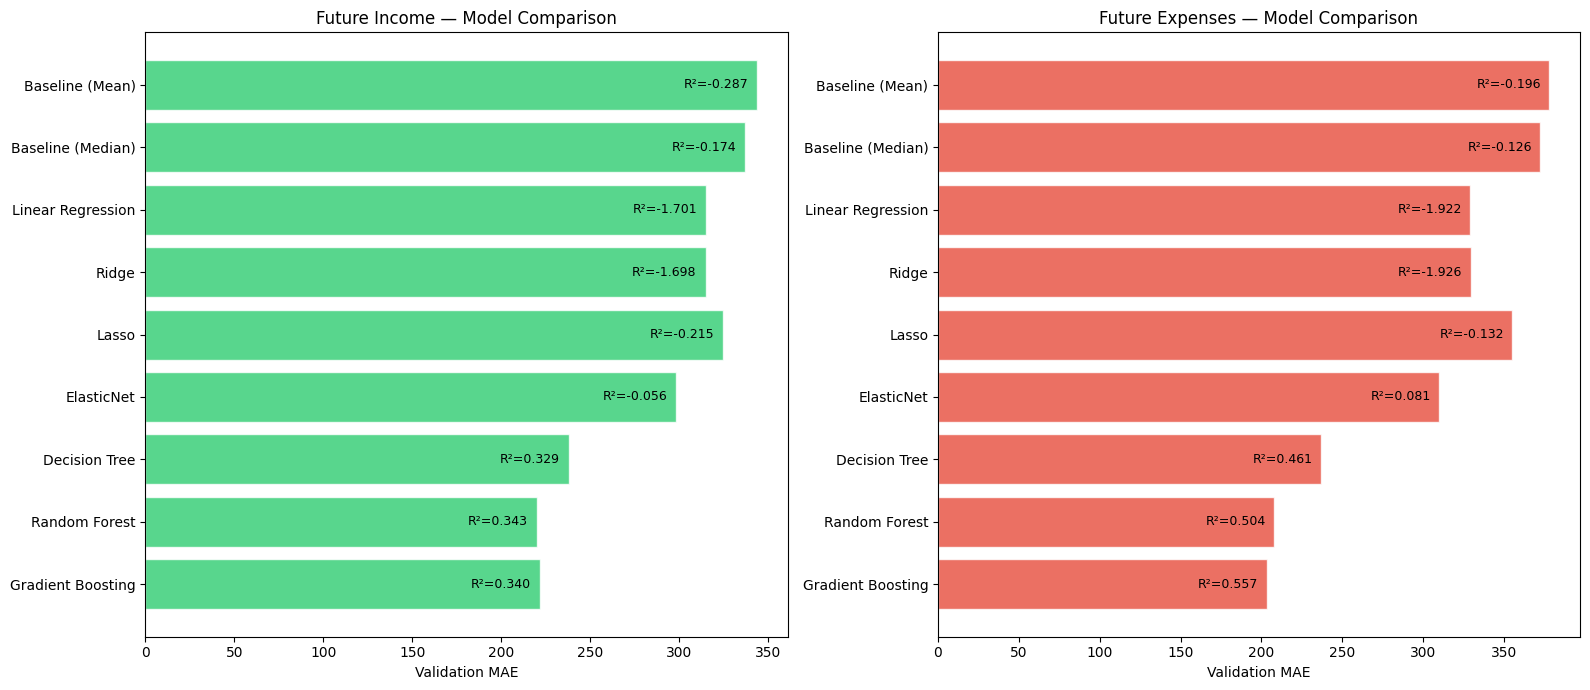

In [ ]:
# ── Model comparison bar chart ───────────────────────────────
# Horizontal bars sorted by MAE; R² annotated inside each bar.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, tgt in enumerate(['income', 'expenses']):
    names = list(results[tgt].keys())
    maes  = [results[tgt][m]['val_mae'] for m in names]
    r2s   = [results[tgt][m]['val_r2']  for m in names]
    color = '#2ecc71' if tgt == 'income' else '#e74c3c'

    ax   = axes[i]
    bars = ax.barh(names, maes, color=color,
                   alpha=0.8, edgecolor='white')
    ax.set_xlabel('Validation MAE')
    ax.set_title(f'Future {tgt.title()} — Model Comparison')
    ax.invert_yaxis()

    # Annotate R² inside each bar
    for bar, r2 in zip(bars, r2s):
        ax.text(
            bar.get_width() - 5,
            bar.get_y() + bar.get_height() / 2,
            f'R²={r2:.3f}',
            va='center', ha='right',
            fontsize=9, color='black',
        )

plt.tight_layout()
plt.show()

In [ ]:
# ── Select best model per target ─────────────────────────────
# Best = lowest validation MAE, excluding baselines.
# Report percentage lift over the mean baseline.

best_models = {}
for target in ['income', 'expenses']:
    real = {
        k: v for k, v in results[target].items()
        if 'Baseline' not in k
    }
    best_name = min(real, key=lambda m: real[m]['val_mae'])
    best_models[target] = {'name': best_name, **real[best_name]}

    baseline = results[target]['Baseline (Mean)']
    lift = (
        (baseline['val_mae'] - real[best_name]['val_mae'])
        / baseline['val_mae'] * 100
    )
    print(
        f"{target}: {best_name} "
        f"(MAE={real[best_name]['val_mae']:.1f}, "
        f"{lift:.0f}% lift over mean baseline)"
    )

income: Random Forest (MAE=220.0, 36% lift over mean baseline)
expenses: Gradient Boosting (MAE=203.2, 46% lift over mean baseline)


#  Section 13 — Final Evaluation on Test Set

In [ ]:
# ============================================================
# Section 13: Final Evaluation on Test Set
# Refit best models on train+val combined, then evaluate
# on the held-out test set (touched only once).
#
# Refitting on train+val gives the model more data before
# final evaluation — this is standard ML practice.
# ============================================================

test_results = {}
for target, y_tv, y_te in [
    ('income',   y_inc_trainval, y_inc_test),
    ('expenses', y_exp_trainval, y_exp_test),
]:
    best  = best_models[target]
    model = best['pipeline'].named_steps['model']

    # Rebuild fresh pipeline with same hyperparameters
    fresh = build_pipeline(
        type(model)(**model.get_params()),
        target=target,
    )

    # Fit on train+val, predict on test
    if best['use_log']:
        fresh.fit(X_trainval, np.log1p(y_tv))
        pred = np.maximum(
            np.expm1(fresh.predict(X_test)), 0
        )
    else:
        fresh.fit(X_trainval, y_tv)
        pred = fresh.predict(X_test)

    mae = mean_absolute_error(y_te, pred)
    r2  = r2_score(y_te, pred)

    test_results[target] = {
        'pipeline': fresh,
        'y_pred':   pred,
        'y_true':   y_te,
        'mae':      mae,
        'r2':       r2,
    }
    print(f"{target}: MAE={mae:.1f}, R²={r2:.4f} "
          f"({best['name']})")

income: MAE=218.6, R²=0.3670 (Random Forest)
expenses: MAE=233.4, R²=0.4348 (Gradient Boosting)


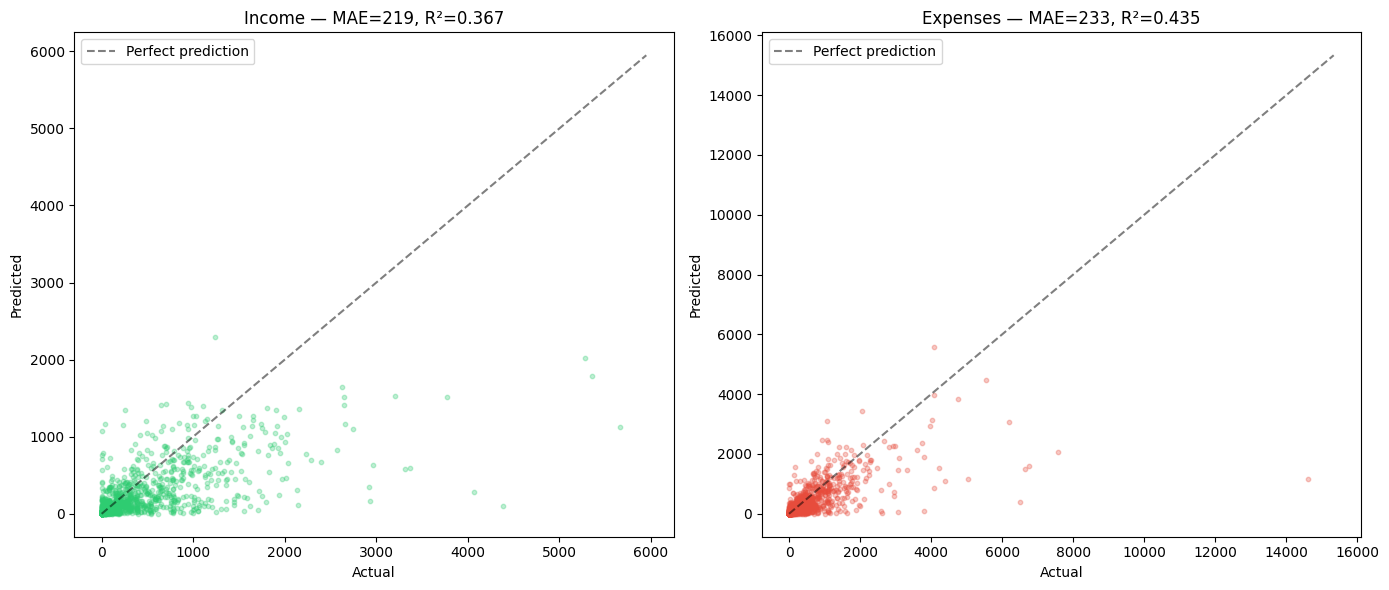

In [ ]:
# ── Predicted vs Actual scatter plot ─────────────────────────
# Points near the dashed diagonal = accurate predictions.
# Systematic deviation above/below = model bias.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (target, color) in enumerate([
    ('income',   '#2ecc71'),
    ('expenses', '#e74c3c'),
]):
    ax   = axes[i]
    true = test_results[target]['y_true']
    pred = test_results[target]['y_pred']
    lim  = max(true.max(), pred.max()) * 1.05

    ax.scatter(true, pred, alpha=0.3, s=10, color=color)
    ax.plot([0, lim], [0, lim], 'k--',
            alpha=0.5, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(
        f'{target.title()} — '
        f'MAE={test_results[target]["mae"]:.0f}, '
        f'R²={test_results[target]["r2"]:.3f}'
    )
    ax.legend()

plt.tight_layout()
plt.show()

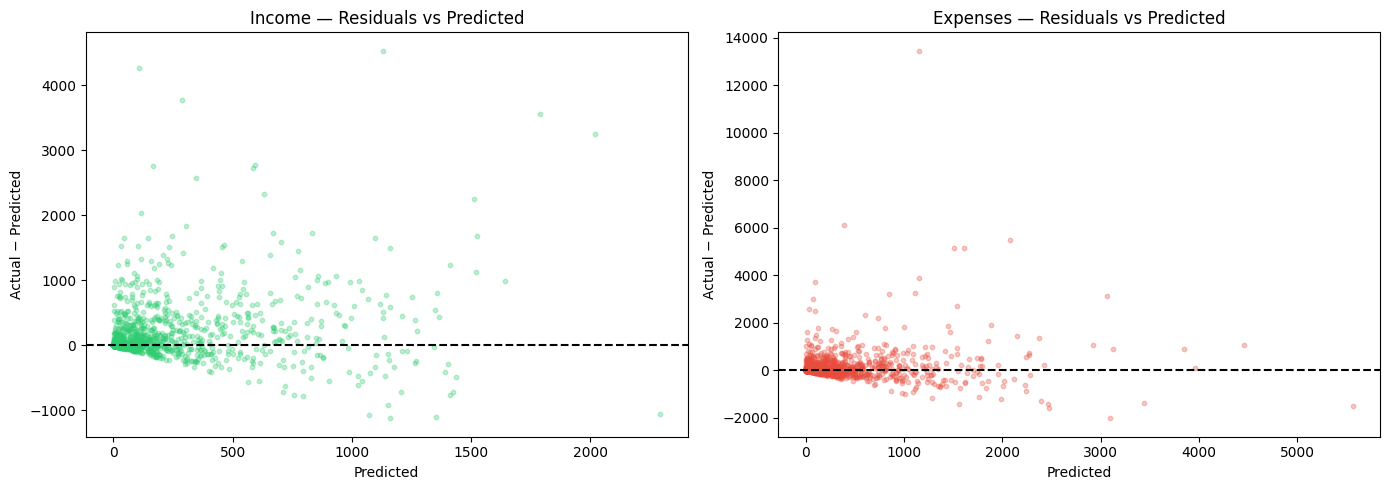

In [ ]:
# ── Residual plot ────────────────────────────────────────────
# Residual = Actual - Predicted
# Ideal: points randomly scattered around y=0
# Pattern in residuals = model missing some structure

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (target, color) in enumerate([
    ('income',   '#2ecc71'),
    ('expenses', '#e74c3c'),
]):
    ax        = axes[i]
    true      = test_results[target]['y_true']
    pred      = test_results[target]['y_pred']
    residuals = true.values - pred

    ax.scatter(pred, residuals, alpha=0.3, s=10, color=color)
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual − Predicted')
    ax.set_title(f'{target.title()} — Residuals vs Predicted')

plt.tight_layout()
plt.show()

# Section 14 — Feature Importance Analysis

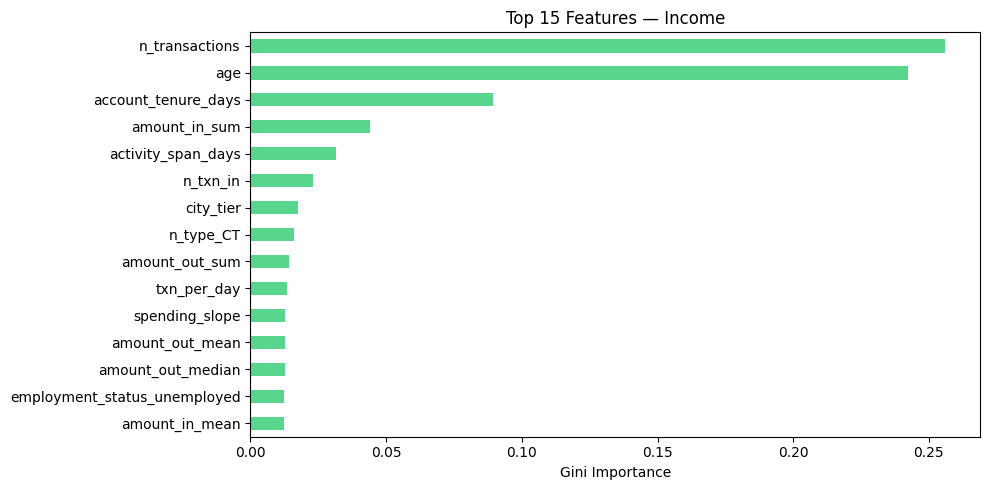

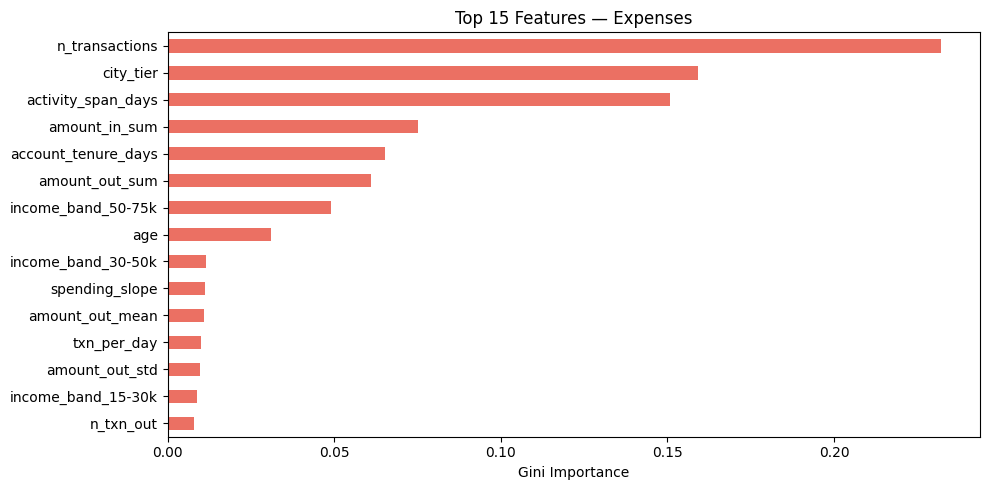

In [ ]:
# ============================================================
# Section 14: Feature Importance Analysis
# Extract Gini importance scores from tree-based models.
# Top 15 features shown per target — reveals which signals
# drive income vs expense predictions differently.
# ============================================================

def get_feature_names(pipeline):
    """
    Extract clean feature names from a fitted Pipeline.
    Strips 'num__' and 'cat__' prefixes added by
    ColumnTransformer for cleaner plot labels.
    """
    ct = pipeline.named_steps['preprocess']
    try:
        names = ct.get_feature_names_out()
    except AttributeError:
        num = ct.transformers_[0][2]
        cat = (
            ct.transformers_[1][1]
            .get_feature_names_out(ct.transformers_[1][2])
        )
        names = list(num) + list(cat)

    # Strip transformer prefixes
    clean = [
        n.replace('num__', '').replace('cat__', '')
        for n in names
    ]
    return clean


for target in ['income', 'expenses']:
    pipe  = test_results[target]['pipeline']
    model = pipe.named_steps['model']

    # Skip models without feature_importances_ (e.g. linear)
    if not hasattr(model, 'feature_importances_'):
        continue

    names = get_feature_names(pipe)
    imp   = pd.Series(
        model.feature_importances_, index=names,
    ).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    imp.sort_values().plot.barh(
        ax=ax,
        color='#2ecc71' if target == 'income' else '#e74c3c',
        alpha=0.8,
    )
    ax.set_title(f'Top 15 Features — {target.title()}')
    ax.set_xlabel('Gini Importance')
    plt.tight_layout()
    plt.show()